In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
%load_ext cudf.pandas
import pandas as pd

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [10]:
import pandas as pd
import joblib
import numpy as np

print("1. Loading processed data (Time Grid & Lags)...")
# Download the file you saved previously
demand_data_path = "/content/drive/MyDrive/Full_Taxi_data/processed_taxi_data_ML1(6h).parquet"
df_processed = pd.read_parquet(demand_data_path)

print("2. Download the request model to generate the Demand Forecast feature...")
# Make sure to include the name of the model you saved (for example lgbm_demand_model_ml6.pkl)
demand_model_path = "/content/drive/MyDrive/Full_Taxi_data/lgbm_demand_model_ml1(6h).pkl"
demand_model = joblib.load(demand_model_path)

# Define the features we used in the request model
demand_features = [
    'PULocationID', 'pickup_hour', 'day_of_week', 'is_weekend',
    'temp_c', 'rain_mm', 'is_rain', 'weather_code', 'is_holiday',
    'lag_1_6h', 'lag_2_6h', 'lag_4_6h', 'rolling_mean_24h'
]

# Convert categorical variables (necessary for LightGBM)
cat_cols = ['PULocationID', 'pickup_hour', 'day_of_week', 'is_weekend', 'is_rain', 'weather_code', 'is_holiday']
for col in cat_cols:
    df_processed[col] = df_processed[col].astype('category')

1. تحميل البيانات المعالجة (Time Grid & Lags)...
2. تحميل موديل الطلب لتوليد ميزة الـ Demand Forecast...


In [11]:
# Generate demand forecast and round to nearest integer (Fixing the decimal issue)
df_processed['forecasted_demand_6h'] = demand_model.predict(df_processed[demand_features])
df_processed['forecasted_demand_6h'] = np.maximum(0, df_processed['forecasted_demand_6h'])
df_processed['forecasted_demand_6h'] = np.round(df_processed['forecasted_demand_6h'], 0) # Rounding to integer

In [12]:
# 3. Load Raw Financial Data
print("Loading basic financial data...")
raw_data_path = "/content/drive/MyDrive/Full_Taxi_data/merged_taxi_data_v3.parquet"
financial_cols = ['tpep_pickup_datetime', 'PULocationID', 'total_amount', 'fare_amount', 'tip_amount']
df_raw_finance = pd.read_parquet(raw_data_path, columns=financial_cols)

جاري تحميل البيانات المالية الأساسية...


In [13]:
# Create 6-hour buckets for financial data
df_raw_finance['time_bucket_6H'] = df_raw_finance['tpep_pickup_datetime'].dt.floor('6h')

# Aggregate financials per zone per 6 hours
print("Revenues are being collected...")
agg_finance = df_raw_finance.groupby(['PULocationID', 'time_bucket_6H']).agg(
    total_revenue=('total_amount', 'sum'),
    avg_fare=('fare_amount', 'mean'),
    avg_tip=('tip_amount', 'mean')
).reset_index()

جاري تجميع الإيرادات...


In [14]:
# 4. Merge Everything Together
print("Data consolidation and financial feature engineering underway...")
df_revenue_master = pd.merge(df_processed, agg_finance, on=['PULocationID', 'time_bucket_6H'], how='left')

# Fill missing financial data with 0.0 (Zero Padding)
df_revenue_master['total_revenue'] = df_revenue_master['total_revenue'].fillna(0.0)
df_revenue_master['avg_fare'] = df_revenue_master['avg_fare'].fillna(0.0)
df_revenue_master['avg_tip'] = df_revenue_master['avg_tip'].fillna(0.0)

جاري دمج البيانات وهندسة الميزات المالية...


In [15]:
# 5. Financial Feature Engineering
# Calculate Tip Rate
df_revenue_master['tip_rate'] = np.where(df_revenue_master['avg_fare'] > 0,
                                         df_revenue_master['avg_tip'] / df_revenue_master['avg_fare'],
                                         0.0)

# Create Financial Lags (Previous 6 hours revenue and 24 hours rolling mean)
df_revenue_master['rev_lag_1_6h'] = df_revenue_master.groupby('PULocationID')['total_revenue'].shift(1)
df_revenue_master['rev_rolling_mean_24h'] = df_revenue_master.groupby('PULocationID')['total_revenue'].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean()
)

/usr/local/lib/python3.12/dist-packages/cudf/pandas/fast_slow_proxy.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return fn(*args, **kwargs)


In [16]:
# 6. Set the Target (Next 6 Hours Revenue)
df_revenue_master['target_revenue_next_6h'] = df_revenue_master.groupby('PULocationID')['total_revenue'].shift(-1)

# Drop boundaries (NaNs caused by shift)
df_final_revenue = df_revenue_master.dropna().reset_index(drop=True)

print("--------------------------------------------------")
print("✅Financial data ready for training!")
print(f"Total rows: {len(df_final_revenue)}")

# View the final dataset specifically for Zone 1 to check the values
cols_to_check = ['time_bucket_6H', 'PULocationID', 'forecasted_demand_6h', 'total_revenue', 'rev_lag_1_6h', 'target_revenue_next_6h']
print(df_final_revenue[df_final_revenue['PULocationID'] == 1][cols_to_check].head(10))

--------------------------------------------------
✅ البيانات المالية جاهزة للتدريب!
إجمالي الصفوف: 734559
       time_bucket_6H PULocationID  forecasted_demand_6h  total_revenue  \
0 2024-01-02 06:00:00            1                   1.0       0.000000   
1 2024-01-02 12:00:00            1                   0.0       0.000000   
2 2024-01-02 18:00:00            1                   0.0      97.000000   
3 2024-01-03 00:00:00            1                   1.0       0.000000   
4 2024-01-03 06:00:00            1                   0.0       0.000000   
5 2024-01-03 12:00:00            1                   0.0     222.949997   
6 2024-01-03 18:00:00            1                   0.0       0.000000   
7 2024-01-04 00:00:00            1                   1.0       0.000000   
8 2024-01-04 06:00:00            1                   0.0       0.000000   
9 2024-01-04 12:00:00            1                   0.0     126.000000   

   rev_lag_1_6h  target_revenue_next_6h  
0      0.000000          

In [18]:

# ==================================================
# 1. Target Column Validation (Checking Future Shift)
# ==================================================
print("==================================================")
print("🔍 1. Test the accuracy of the financial goal column (Target Validation)")
print("==================================================")

# Create a temporary column that calculates the "future" programmatically for all zones
expected_target = df_final_revenue.groupby('PULocationID')['total_revenue'].shift(-1)

# Compare the temporary column with the one we created in the data
# We use np.isclose instead of (==) because financial figures might be floats with long decimals
match_check = np.isclose(df_final_revenue['target_revenue_next_6h'], expected_target, equal_nan=True)

# Exclude the last row of each zone (because it will naturally be NaN)
valid_rows = expected_target.notna()
accuracy = match_check[valid_rows].mean() * 100

if accuracy == 100.0:
    print("✅ Excellent! All rows checked. Target column (target_revenue_next_6h) is 100% identical to the future.")
else:
    print(f"❌ There was an error in the target configuration! The match percentage is only {accuracy}%.")

# ==================================================
# 2. General Data Health Check (Missing & Negative Values)
# ==================================================
print("\n==================================================")
print("📊 2. General health check of financial statements")
print("==================================================")

# 1. Check for Missing Values (NaNs)
missing_values = df_final_revenue.isnull().sum()
if missing_values.sum() == 0:
    print("✅ There are no missing values ​​(NaNs) in the data. (Zero padding successful)")
else:
    print("⚠️ Warning: There are missing values ​​in the following columns:")
    print(missing_values[missing_values > 0])

# 2. Check for Negative Revenues (Data Error Check)
negative_revenue = (df_final_revenue['total_revenue'] < 0).sum()
if negative_revenue == 0:
    print("✅ There are no negative financial values ​​in the Revenue column.")
else:
    print(f"⚠️ Warning: There is {negative_revenue} row with negative revenue. Better zero it out.")
    # You can uncomment the line below to reset them to 0 if found
    # df_final_revenue['total_revenue'] = np.maximum(0, df_final_revenue['total_revenue'])

# 3. Quick Financial Statistics Summary
print("\n---Summary Statistics---")
cols_to_describe = ['total_revenue', 'avg_fare', 'tip_rate', 'target_revenue_next_6h']
print(df_final_revenue[cols_to_describe].describe().round(2))

print("\n==================================================")
print("Financials are all ready for training! 💰🚀")
print("==================================================")

🔍 1. اختبار دقة عمود الهدف المالي (Target Validation)
✅ ممتاز! تم فحص جميع الصفوف. عمود الهدف (target_revenue_next_6h) مطابق تماماً للمستقبل بنسبة 100%.

📊 2. الفحص العام لصحة البيانات المالية (Health Check)
✅ لا توجد أي قيم مفقودة (NaNs) في البيانات. (حشو الأصفار ناجح).
✅ لا توجد قيم مالية سالبة في عمود الإيرادات.

--- إحصائيات سريعة للأموال (Summary Statistics) ---
       total_revenue   avg_fare   tip_rate  target_revenue_next_6h
count      734559.00  734559.00  734559.00               734559.00
mean         3073.30      20.85       0.05                 3074.18
std         10858.67      17.12       0.08                10861.92
min             0.00       0.00       0.00                    0.00
25%            12.57       7.90       0.00                   12.59
50%           143.24      19.90       0.00                  143.33
75%           836.86      29.82       0.10                  837.21
max        273068.34     487.40       1.00               273068.34

البيانات المالية جاهزة تما

In [19]:
import numpy as np

print("==================================================")
print("🛠️ 3. Outlier Handling - Capping)")
print("==================================================")

#1. Total Revenue & Target
# We will use the 99.9th Percentile to maintain real peak times numbers and reduce imaginary numbers
revenue_cap = df_final_revenue['total_revenue'].quantile(0.999)
target_cap = df_final_revenue['target_revenue_next_6h'].quantile(0.999)

df_final_revenue['total_revenue'] = df_final_revenue['total_revenue'].clip(upper=revenue_cap)
df_final_revenue['target_revenue_next_6h'] = df_final_revenue['target_revenue_next_6h'].clip(upper=target_cap)

# Update the lag feature after adjusting the revenues to be consistent
df_final_revenue['rev_lag_1_6h'] = df_final_revenue.groupby('PULocationID')['total_revenue'].shift(1).fillna(0)

#2. Avg Fare Processing
# Any fare above the 99th Percentile will fall to this limit (usually it will be in the range of 100-150 dollars)
fare_cap = df_final_revenue['avg_fare'].quantile(0.99)
df_final_revenue['avg_fare'] = df_final_revenue['avg_fare'].clip(upper=fare_cap)

#3. Tip Rate Processing
#We will limit the tip to 50% (0.5) to avoid registration errors (as the tip is many times the fare)
df_final_revenue['tip_rate'] = df_final_revenue['tip_rate'].clip(upper=0.5)

print(f"✅ Revenues are capped at: {revenue_cap:.2f} dollars")
print(f"✅ The average fare has been capped at: {fare_cap:.2f} dollars")
print("\n--- Statistics after processing---")
cols_to_describe = ['total_revenue', 'avg_fare', 'tip_rate', 'target_revenue_next_6h']
print(df_final_revenue[cols_to_describe].describe().round(2))

🛠️ 3. معالجة القيم الشاذة (Outlier Handling - Capping)
✅ تم وضع سقف للإيرادات عند: 156737.38 دولار
✅ تم وضع سقف لمتوسط الأجرة عند: 70.00 دولار

--- الإحصائيات بعد المعالجة ---
       total_revenue   avg_fare   tip_rate  target_revenue_next_6h
count      734559.00  734559.00  734559.00               734559.00
mean         3046.19      20.65       0.05                 3047.07
std         10408.10      16.14       0.08                10411.45
min             0.00       0.00       0.00                    0.00
25%            12.57       7.90       0.00                   12.59
50%           143.24      19.90       0.00                  143.33
75%           836.86      29.82       0.10                  837.21
max        156737.38      70.00       0.50               156769.91


In [20]:
print("==================================================")
print("⏳ 4. Advanced Lags Engineering")
print("==================================================")

#1. Add the revenue of the same time last week (Lag 1 Week)
# Week = 7 days * 4 periods per day (because the bucket is 6 hours) = 28
df_final_revenue['rev_lag_1_week'] = df_final_revenue.groupby('PULocationID')['total_revenue'].shift(28).fillna(0)

#2. Average revenue for the same zone in the last 7 days (Rolling Mean 7 Days)
df_final_revenue['rev_rolling_mean_7d'] = df_final_revenue.groupby('PULocationID')['total_revenue'].transform(
    lambda x: x.rolling(window=28, min_periods=1).mean()
)

#3. Average revenue for the same zone in the last 30 days (Rolling Mean 30 Days)
df_final_revenue['rev_rolling_mean_30d'] = df_final_revenue.groupby('PULocationID')['total_revenue'].transform(
    lambda x: x.rolling(window=120, min_periods=1).mean() # 30 * 4 = 120
)

# Delete any new rows that still contain NaNs due to Shift
df_final_revenue = df_final_revenue.dropna().reset_index(drop=True)

print("✅ Week and month features have been added successfully!")
print(f"Total rows ready for final training: {len(df_final_revenue)}")

⏳ 4. هندسة الميزات الزمنية المتقدمة (Advanced Lags)


/usr/local/lib/python3.12/dist-packages/cudf/pandas/fast_slow_proxy.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return fn(*args, **kwargs)


✅ تم إضافة ميزات الأسبوع والشهر بنجاح!
إجمالي الصفوف الجاهزة للتدريب النهائي: 734559


In [21]:
print("==================================================")
print("💾 5. Save the final data to Google Drive")
print("==================================================")

# Specify the save path (in the same folder as your project)
save_path = "/content/drive/MyDrive/Full_Taxi_data/final_revenue_data_ml5.parquet"

# Save the data in parquet format
df_final_revenue.to_parquet(save_path, index=False)

print(f"✅ The final data was successfully saved to:")
print(save_path)
print("Now the data is safe, and you can start the modeling phase at your convenience! 🚀")

💾 5. حفظ البيانات النهائية في Google Drive
✅ تم حفظ البيانات النهائية بنجاح في:
/content/drive/MyDrive/Full_Taxi_data/final_revenue_data_ml5.parquet
دلوقتي الداتا في أمان، وتقدر تبدأ مرحلة الـ Modeling براحتك! 🚀


In [23]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 15.3 MB/s eta 0:00:00


In [24]:
import lightgbm as lgb
import optuna
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

print("==================================================")
print("🚀 6. Segmenting data time-wise and searching for the best parameters with Optuna")
print("==================================================")

#1. Define features and purpose
# Make sure that these are the same column names that we prepared
features = [
    'PULocationID', 'pickup_hour', 'day_of_week', 'is_weekend',
    'forecasted_demand_6h', 'rev_lag_1_6h', 'rev_lag_1_week',
    'rev_rolling_mean_7d', 'rev_rolling_mean_30d', 'avg_fare', 'tip_rate'
]
target = 'target_revenue_next_6h'

# Chronological order of data (very important before dividing)
df_final_revenue = df_final_revenue.sort_values('time_bucket_6H').reset_index(drop=True)

#2. Time division (80% Train, 20% Validation)
split_index = int(len(df_final_revenue) * 0.8)

train_data = df_final_revenue.iloc[:split_index]
val_data = df_final_revenue.iloc[split_index:]

X_train, y_train = train_data[features], train_data[target]
X_val, y_val = val_data[features], val_data[target]

print(f"✅ Training data size: {len(X_train)} row")
print(f"✅ Evaluation data size: {len(X_val)} row")

#3. Set up Optuna (Objective Function)
def objective(trial):
    # Search space for parameters
    param = {
        'objective': 'quantile',
        'alpha': 0.5, # P50 (Median)
        'metric': 'quantile',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'random_state': 42,
        'verbose': -1 # To prevent each tree's details from being printed
    }

    # Prepare data for LightGBM
    dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=['PULocationID', 'pickup_hour', 'day_of_week', 'is_weekend'])
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain, categorical_feature=['PULocationID', 'pickup_hour', 'day_of_week', 'is_weekend'])

    # Train the model with Early Stopping
    gbm = lgb.train(
        param,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    # Prediction and error calculation (we used MAE as evaluation criterion for P50)
    preds = gbm.predict(X_val)
    error = mean_absolute_error(y_val, preds)

    return error

#4. Run Optuna
print("\n🔍 Searching for the best parameters... (may take some time)")
study = optuna.create_study(direction='minimize')
# You can increase n_trials to 50 or 100 to get more accurate results if time allows
study.optimize(objective, n_trials=20)

print("\n🎉 Search completed!")
print("Best parameters obtained:")
best_params = study.best_params
for key, value in best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-03 17:05:17,621] A new study created in memory with name: no-name-cf147525-9637-4adc-8929-1d76a231cf8f


🚀 6. تقسيم البيانات زمنياً والبحث عن أفضل البارامترات بـ Optuna
✅ حجم بيانات التدريب: 587647 صف
✅ حجم بيانات التقييم: 146912 صف

🔍 جاري البحث عن أفضل البارامترات... (قد يستغرق بعض الوقت)


[I 2026-03-03 17:06:57,961] Trial 0 finished with value: 420.4930780883222 and parameters: {'learning_rate': 0.08036906490959086, 'num_leaves': 42, 'max_depth': 6, 'feature_fraction': 0.94963097845455, 'bagging_fraction': 0.6153983072423584, 'bagging_freq': 2, 'min_child_samples': 74}. Best is trial 0 with value: 420.4930780883222.
[I 2026-03-03 17:09:52,354] Trial 1 finished with value: 402.5497212813182 and parameters: {'learning_rate': 0.011369539638721006, 'num_leaves': 123, 'max_depth': 15, 'feature_fraction': 0.9414006513925242, 'bagging_fraction': 0.9826429708130922, 'bagging_freq': 7, 'min_child_samples': 82}. Best is trial 1 with value: 402.5497212813182.
[I 2026-03-03 17:11:57,098] Trial 2 finished with value: 404.35390716279045 and parameters: {'learning_rate': 0.05437753434058585, 'num_leaves': 125, 'max_depth': 9, 'feature_fraction': 0.7739805088540431, 'bagging_fraction': 0.7433478495836607, 'bagging_freq': 4, 'min_child_samples': 11}. Best is trial 1 with value: 402.5497


🎉 تم الانتهاء من البحث!
أفضل بارامترات تم الحصول عليها:
  learning_rate: 0.016679013024147617
  num_leaves: 149
  max_depth: 13
  feature_fraction: 0.6622809461632709
  bagging_fraction: 0.9163477863155614
  bagging_freq: 5
  min_child_samples: 57


🚀 7. بناء وتقييم موديل الإيرادات النهائي (P50 & P90)

⏳ جاري تدريب موديل P50 (التوقع المتوسط)...
[100]	training's quantile: 571.944	valid_1's quantile: 631.49
[200]	training's quantile: 280.058	valid_1's quantile: 330.771
[300]	training's quantile: 176.196	valid_1's quantile: 226.302
[400]	training's quantile: 157.937	valid_1's quantile: 206.447
[500]	training's quantile: 153.803	valid_1's quantile: 202.341
[600]	training's quantile: 152.3	valid_1's quantile: 201.164
[700]	training's quantile: 151.289	valid_1's quantile: 200.482
[800]	training's quantile: 150.661	valid_1's quantile: 200.096
[900]	training's quantile: 150	valid_1's quantile: 199.742
[1000]	training's quantile: 149.468	valid_1's quantile: 199.467
[1100]	training's quantile: 149.04	valid_1's quantile: 199.258
[1200]	training's quantile: 148.558	valid_1's quantile: 199.068
[1300]	training's quantile: 148.069	valid_1's quantile: 198.884
[1400]	training's quantile: 147.733	valid_1's quantile: 198.73
[1500]	training's quantil

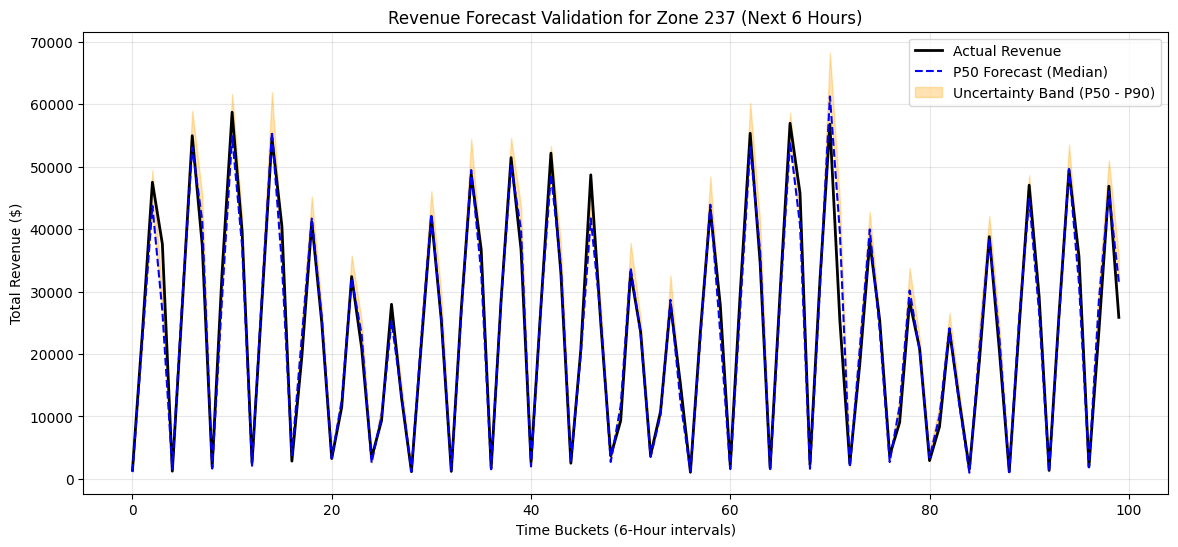

In [25]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("==================================================")
print("🚀 7. Build and evaluate the final revenue model (P50 & P90)")
print("==================================================")

#1. Definition of the parameters obtained from Optuna
best_params = {
    'objective': 'quantile',
    'metric': 'quantile',
    'boosting_type': 'gbdt',
    'learning_rate': 0.016679013024147617,
    'num_leaves': 149,
    'max_depth': 13,
    'feature_fraction': 0.6622809461632709,
    'bagging_fraction': 0.9163477863155614,
    'bagging_freq': 5,
    'min_child_samples': 57,
    'random_state': 42,
    'verbose': -1
}

# Prepare the LightGBM datasets (make sure that X_train, y_train, X_val, y_val are ready from the previous step)
categorical_features = ['PULocationID', 'pickup_hour', 'day_of_week', 'is_weekend']
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
dval = lgb.Dataset(X_val, label=y_val, reference=dtrain, categorical_feature=categorical_features)

# ---------------------------------------------------------
#2. P50 Model Training (Intermediate/Basic Scenario)
# ---------------------------------------------------------
print("\n⏳ Training the P50 (medium forecast) model...")
params_p50 = best_params.copy()
params_p50['alpha'] = 0.5

model_p50 = lgb.train(
    params_p50,
    dtrain,
    num_boost_round=1500, # We increased the rounds because the learning rate is low
    valid_sets=[dtrain, dval],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=100)]
)

# ---------------------------------------------------------
#3. P90 Model Training (Peak/Expected Maximum Scenario)
# ---------------------------------------------------------
print("\n⏳ P90 model training (peak prediction)...")
params_p90 = best_params.copy()
params_p90['alpha'] = 0.9

model_p90 = lgb.train(
    params_p90,
    dtrain,
    num_boost_round=1500,
    valid_sets=[dtrain, dval],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=100)]
)

# ---------------------------------------------------------
#4. Evaluation
# ---------------------------------------------------------
print("\n==================================================")
print("📊 8. Evaluation Metrics")
print("==================================================")

# Extract forecasts
preds_p50 = model_p50.predict(X_val)
preds_p90 = model_p90.predict(X_val)

# Calculate the MAE and RMSE for the P50 model
mae_p50 = mean_absolute_error(y_val, preds_p50)
rmse_p50 = np.sqrt(mean_squared_error(y_val, preds_p50))

print(f"✅ Mean Absolute Error (MAE) of P50: {mae_p50:.2f}$")
print(f"✅ Root Mean Square Error (RMSE) of P50: {rmse_p50:.2f}$")

# P90 (Quantile Coverage) evaluation
# It is assumed that 90% of actual revenues are less than or equal to the P90 forecast
p90_coverage = (y_val <= preds_p90).mean() * 100
print(f"✅ Coverage percentage of P90 (Coverage): {p90_coverage:.2f}% (ideal is about 90%)")

# ---------------------------------------------------------
#5. Visual Validation (plot results for a specific area)
# ---------------------------------------------------------
# We will select a specific area (PULocationID) from the evaluation data to see what the expectations look like
sample_zone = 237 # Upper East Side South as an example (you can change the number)
zone_mask = X_val['PULocationID'] == sample_zone

if zone_mask.sum() > 0:
    actual_trend = y_val[zone_mask].values[:100] # first 100 time periods
    p50_trend = preds_p50[zone_mask][:100]
    p90_trend = preds_p90[zone_mask][:100]

    plt.figure(figsize=(14, 6))
    plt.plot(actual_trend, label='Actual Revenue', color='black', linewidth=2)
    plt.plot(p50_trend, label='P50 Forecast (Median)', color='blue', linestyle='--')
    plt.fill_between(range(len(actual_trend)), p50_trend, p90_trend, color='orange', alpha=0.3, label='Uncertainty Band (P50 - P90)')

    plt.title(f'Revenue Forecast Validation for Zone {sample_zone} (Next 6 Hours)')
    plt.xlabel('Time Buckets (6-Hour intervals)')
    plt.ylabel('Total Revenue ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print(f"The region {sample_zone} does not exist in the validation data.")

In [26]:
import pandas as pd
import numpy as np

print("==================================================")
print("🧪 Model logic test (Sanity Check)")
print("==================================================")

# Create test data (two scenarios)
test_data = pd.DataFrame({
    'PULocationID': [237, 5], #237: Manhattan (traffic) | 5: Staten Island (Hadia)
    'pickup_hour': [18, 0], #18: PM peak time | 0: midnight
    'day_of_week': [3, 6], #3: Thursday (occupied) | 6: Sunday (off)
    'is_weekend': [0, 1], #0: working day | 1: Weekend
    'forecasted_demand_6h': [1500, 20], # Very high expected demand | Weak request
    'rev_lag_1_6h': [25000, 300], # revenue for the last 6 hours
    'rev_lag_1_week': [26500, 350], # Revenue at the same time last week
    'rev_rolling_mean_7d': [24000, 250], # Average of the last 7 days
    'rev_rolling_mean_30d': [23500, 280], # Average of the last 30 days
    'avg_fare': [25.5, 45.0], # Average fare (short trips) | High fare (long travel)
    'tip_rate': [0.15, 0.05] #High tip | A small tip
})

# Convert categorical columns to the same type of training data
categorical_features = ['PULocationID', 'pickup_hour', 'day_of_week', 'is_weekend']
for col in categorical_features:
    test_data[col] = test_data[col].astype('category')

# Make predictions
pred_p50 = model_p50.predict(test_data)
pred_p90 = model_p90.predict(test_data)

# Print the results in an organized manner
for i, zone in enumerate(["Manhattan (prime time)", "outskirts (midnight)"]):
    print(f"\n📍 Scenario {i+1}: {zone}")
    print(f" 🔹 Average forecast (P50 - usual revenue): ${pred_p50[i]:,.2f}")
    print(f" 🔸 Predicted peak (P90 - expected maximum): ${pred_p90[i]:,.2f}")

🧪 اختبار منطقية الموديل (Sanity Check)

📍 سيناريو 1: مانهاتن (وقت الذروة)
  🔹 التوقع المتوسط (P50 - الإيراد المعتاد): $28,248.96
  🔸 توقع الذروة (P90 - الحد الأقصى المتوقع): $36,884.90

📍 سيناريو 2: أطراف المدينة (منتصف الليل)
  🔹 التوقع المتوسط (P50 - الإيراد المعتاد): $579.89
  🔸 توقع الذروة (P90 - الحد الأقصى المتوقع): $899.22


In [27]:
import joblib

# Save models
joblib.dump(model_p50, '/content/drive/MyDrive/Full_Taxi_data/lgbm_revenue_p50_ml5.pkl')
joblib.dump(model_p90, '/content/drive/MyDrive/Full_Taxi_data/lgbm_revenue_p90_ml5.pkl')

print("✅ Revenue models saved successfully!")

✅ تم حفظ موديلات الإيرادات بنجاح!
